# Testing a two model structure to isolate the text sentiment from the market data

Ok so I THINK that our models are struggling because they are trying to learn both the market movement patterns and the sentiment analysis from text at the same time. 

Our TF IDF vectors are extremely large, with thousands of dimensions, while our market data is only 2 features.

I think the models aren't even using the market data because it's so insignificant compared to the thousands of text features.

### So what if we separate the two tasks?

I believe this is called stacking.

We will have one model analyze the sentiment of the text, then feed the sentiment along with the pct_change and volume into our second model to make a decision.

After doing additional research, I think we should use a tree based model for the second model, since they can capture non-linear relationships and interactions between features better than linear models. The main reason I thought of this is because it would be able to capture the idea that when the volume is large, no matter if the pct_change is positive or negative, it will increase whatever the effect of it is. That cannot be modeled linearly. 

For the first model, we can keep our SGDClassifier, after we tuned the parameters using GridSearchCV in Phase 3, it performed the best out of all our models. 

For the second model, I think we should try XGBoost since it's another tree method that we didn't cover in class and supposedly can be more accurate.

Before we begin, we have to very carefully think about DATA LEAKAGE!

The issue we could run into is, if we train model A on the entire training set, then use it to generate predictions for model B on the training set, model A will have already seen those examples, so model B will learn to trust model A too much.

We can avoid this by using cross-validation to generate model A's predictions on the training set. This way, model A will only make predictions on examples it hasn't seen during training, giving model B realistic predictions to learn from.

In [136]:
%%capture
%pip install xgboost

In [137]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit

# Training our first model to analyze text sentiment using SGDClassifier

In [138]:
df = pd.read_csv("data/extra_and_merged_data.csv", index_col="date", parse_dates=True)
df.sort_index(inplace=True)

We define our features (X) and target (y)

Our features (X) is comprised of our cleaned text data (X1) and our financial data (X2).

In [139]:
X = df[["summary", "pct_change", "volume"]]
y = df["target"]

Now we split our data for training and testing

DO NOT SHUFFLE because we don't want to mix time series data

In [140]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [141]:
print(f"Training Range: {X_train.index.min()} to {X_train.index.max()}")
print(f"Testing Range:  {X_test.index.min()} to {X_test.index.max()}")

Training Range: 2003-02-20 00:00:00 to 2018-03-23 00:00:00
Testing Range:  2018-03-26 00:00:00 to 2021-12-30 00:00:00


we will use TF-IDF vectorization to convert text into numerical format


In [142]:
text_pipeline = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
        ),
        (
            "sgd",
            SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=1e-4,
                random_state=42,
                max_iter=1000,
            ),
        ),
    ]
)

IMPORTANT BEFORE WE FIT (I originally forgot this oops)

We need to use TimeSeriesSplit to avoid data leakage when generating predictions for the training set

In [143]:
tscv = TimeSeriesSplit(n_splits=5)

In [144]:
meta_predictions = []
meta_indices = []

print("Generating out-of-fold predictions...")
for split_idx, (train_index, test_index) in enumerate(tscv.split(X_train)):
    # Create the fold data
    fold_X_train = X_train['summary'].iloc[train_index]
    fold_y_train = y_train.iloc[train_index]
    fold_X_test = X_train['summary'].iloc[test_index]
    
    # Fit on the past
    text_pipeline.fit(fold_X_train, fold_y_train)
    
    # Predict on the "future" (this fold's test set)
    probs = text_pipeline.predict_proba(fold_X_test)[:, 1]
    
    # Store results
    meta_predictions.append(probs)
    meta_indices.append(test_index)

# Flatten the results
# This array contains predictions for the later part of X_train
train_sentiment_probs = np.concatenate(meta_predictions)
valid_indices = np.concatenate(meta_indices)

# 4. Align Data for the Second Model (XGBoost)
# We create a new training set that only includes rows where we have 
# valid out-of-fold predictions.
X_train_meta = X_train.iloc[valid_indices][['pct_change', 'volume']].copy()
y_train_meta = y_train.iloc[valid_indices]

# Add the sentiment score feature
X_train_meta['sentiment_score'] = train_sentiment_probs

Generating out-of-fold predictions...


Fit this to ONLY the text column of our data

In [145]:
text_pipeline.fit(X_train['summary'], y_train)

,steps,"[('tfidf', ...), ('sgd', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


Now we can generate sentiment scores (basically probabilities), so we convert the messy text vectors into a clean number 0.0 to 1.0 

In [146]:
test_sentiment = text_pipeline.predict_proba(X_test['summary'])[:, 1]
X_test_meta = X_test[['pct_change', 'volume']].copy()
X_test_meta['sentiment_score'] = test_sentiment

Now we make the model

In [147]:
xgb_model = XGBClassifier(
    n_estimators=100,  # number of trees
    max_depth=4,  # maximum depth of each tree
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
)

In [148]:
xgb_model.fit(X_train_meta, y_train_meta)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [149]:
y_pred = xgb_model.predict(X_test_meta)

In [150]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5227

Classification Report:
              precision    recall  f1-score   support

         0.0       0.43      0.29      0.35       413
         1.0       0.56      0.70      0.62       536

    accuracy                           0.52       949
   macro avg       0.50      0.50      0.49       949
weighted avg       0.50      0.52      0.50       949




--- What drove the decision? (Feature Importance) ---
           Feature  Importance
1           volume    0.345014
2  sentiment_score    0.340170
0       pct_change    0.314816


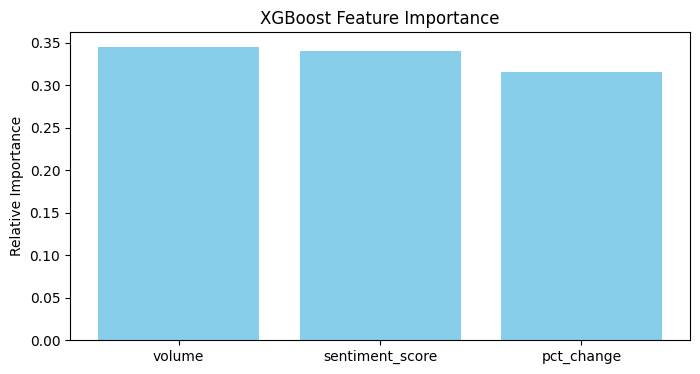

In [151]:
import matplotlib.pyplot as plt

importance = xgb_model.feature_importances_
feature_names = X_train_meta.columns

# Create a DataFrame for nice printing
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

print("\n--- What drove the decision? (Feature Importance) ---")
print(feat_imp)

# Simple Plot
plt.figure(figsize=(8, 4))
plt.bar(feat_imp['Feature'], feat_imp['Importance'], color='skyblue')
plt.title('XGBoost Feature Importance')
plt.ylabel('Relative Importance')
plt.show()

Originally we had 91% reliance on sentiment_score, and the other two were practically nothing. 

After tuning, by preventing data leakage, we have a more balanced feature importance